<figure>
<center>
<img src='https://www.economicas.uba.ar/wp-content/uploads/2020/08/cropped-logo_FCE.png' />
</figure>

# 📊 Visualización de Datos — Matplotlib & Seaborn
### Taller de Programación

---

| Librería | Descripción |
|---|---|
| **Matplotlib** | Base de casi toda la visualización en Python. Control total sobre cada elemento. |
| **Seaborn** | Construida sobre Matplotlib. Menos código, estilos más prolijos, integración directa con DataFrames. |

En cada sección vamos a resolver **el mismo gráfico** con ambas librerías para comparar el código.

### Dataset
Datos sintéticos de ventas: 3 regiones × 4 productos × 12 meses (2026).

---
## 0. Setup y dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi']         = 110
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
sns.set_theme(style='whitegrid', palette='tab10')

np.random.seed(42)

MESES     = ['Ene','Feb','Mar','Abr','May','Jun',
              'Jul','Ago','Sep','Oct','Nov','Dic']
REGIONES  = ['Norte', 'Centro', 'Sur']
PRODUCTOS = ['Laptop', 'Monitor', 'Teclado', 'Mouse']
PRECIO    = {'Laptop': 1200, 'Monitor': 400, 'Teclado': 80, 'Mouse': 35}

filas = []
for mes_idx, mes in enumerate(MESES):
    for region in REGIONES:
        for producto in PRODUCTOS:
            base          = {'Laptop': 30, 'Monitor': 50, 'Teclado': 120, 'Mouse': 200}[producto]
            tendencia     = 1 + mes_idx * 0.03
            estacional    = 1 + 0.25 * np.sin(2 * np.pi * mes_idx / 12 - np.pi / 2)
            region_factor = {'Norte': 1.2, 'Centro': 1.0, 'Sur': 0.8}[region]
            cantidad      = int(base * tendencia * estacional * region_factor
                                * np.random.uniform(0.85, 1.15))
            filas.append({
                'Mes'     : mes,
                'MesNum'  : mes_idx + 1,
                'Region'  : region,
                'Producto': producto,
                'Cantidad': cantidad,
                'Precio'  : PRECIO[producto],
                'Revenue' : cantidad * PRECIO[producto],
            })

df = pd.DataFrame(filas)
print(f"Filas: {len(df)}  |  Revenue total: ${df['Revenue'].sum():,.0f}")
df.head()

Filas: 144  |  Revenue total: $2,996,490


,Mes,MesNum,Region,Producto,Cantidad,Precio,Revenue
0,Ene,1,Norte,Laptop,25,1200,30000
1,Ene,1,Norte,Monitor,51,400,20400
2,Ene,1,Norte,Teclado,115,80,9200
3,Ene,1,Norte,Mouse,185,35,6475
4,Ene,1,Centro,Laptop,20,1200,24000


---
## 1. Line Plot — Evolución temporal

**Dato:** revenue mensual por región.

In [2]:
rev_mes_region = (
    df.groupby(['MesNum', 'Region'])['Revenue']
    .sum().reset_index()
)
rev_mes_region

,MesNum,Region,Revenue
0,1,Centro,49250
1,1,Norte,66075
2,1,Sur,43640
3,2,Centro,55205
4,2,Norte,69325
5,2,Sur,45265
6,3,Centro,64565
7,3,Norte,79885
8,3,Sur,53350
9,4,Centro,72700


#### 🔵 Matplotlib

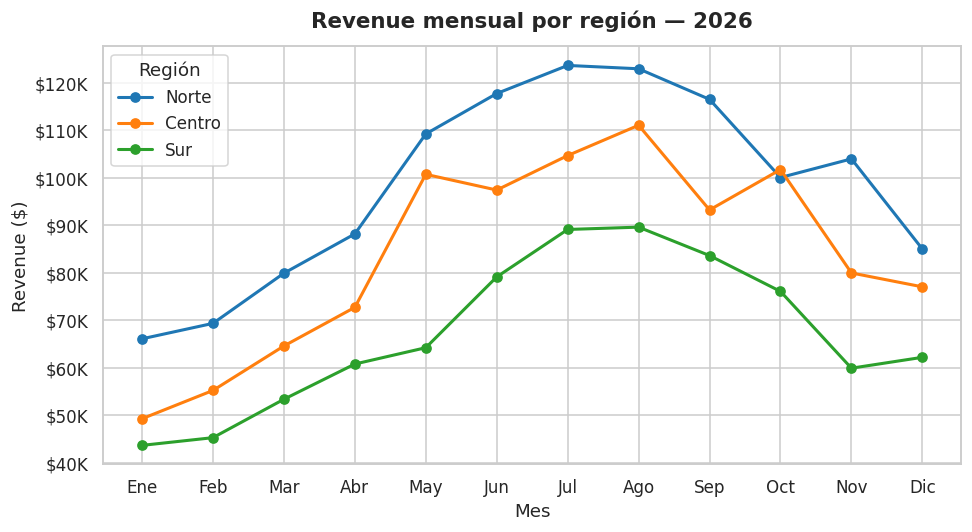

In [3]:
plt.figure(figsize=(9, 5))
for region in REGIONES:
    datos = rev_mes_region[rev_mes_region['Region'] == region]
    plt.plot(MESES, datos['Revenue'], marker='o', linewidth=2, label=region)

plt.title('Revenue mensual por región — 2026', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

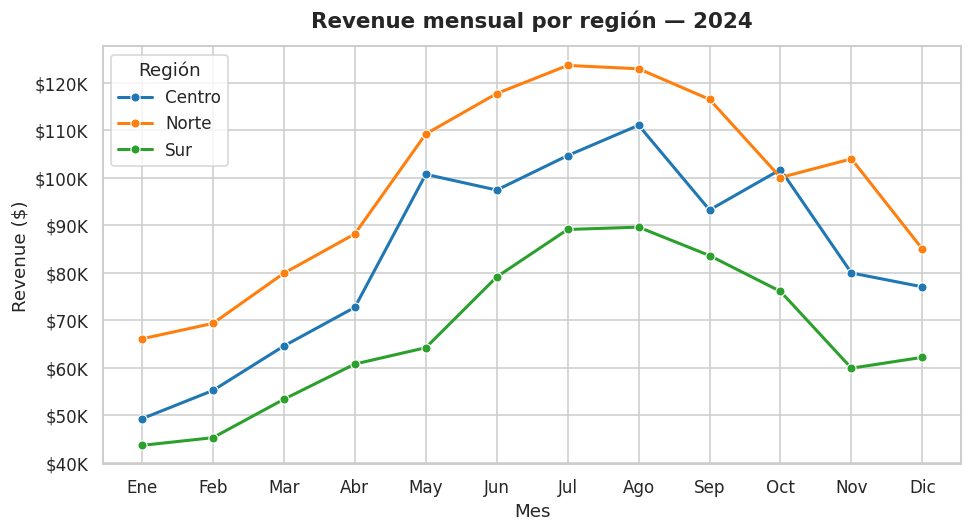

In [4]:
plt.figure(figsize=(9, 5))
sns.lineplot(data=rev_mes_region, x='MesNum', y='Revenue',
             hue='Region', marker='o', linewidth=2)

plt.title('Revenue mensual por región — 2024', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Revenue ($)')
plt.xticks(ticks=range(1, 13), labels=MESES)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()


> **Matplotlib vs Seaborn:** En Matplotlib se itera manualmente sobre los grupos (`for region in REGIONES`) y se llama a `plt.plot()` una vez por grupo. Seaborn hace esto internamente: `hue='Region'` le indica que trace una línea por cada valor único de esa columna.
>
> **Interpretación:** Muestra la **evolución temporal** de una variable. Observar:
> - **Tendencia general**: ¿las líneas suben, bajan o son estables a lo largo del período?
> - **Estacionalidad**: ¿hay picos o valles recurrentes que sugieren un patrón cíclico?
> - **Comparación entre series**: ¿qué región/grupo crece más rápido? ¿las líneas convergen, se separan o se cruzan en algún punto? Un cruce indica que un grupo superó a otro en ese período.


---
## 2. Bar Plot — Comparación entre categorías

**Dato:** revenue total por producto.

In [5]:
rev_prod = (
    df.groupby('Producto')['Revenue']
    .sum().reset_index()
    .sort_values('Revenue', ascending=False)
)

#### 🔵 Matplotlib

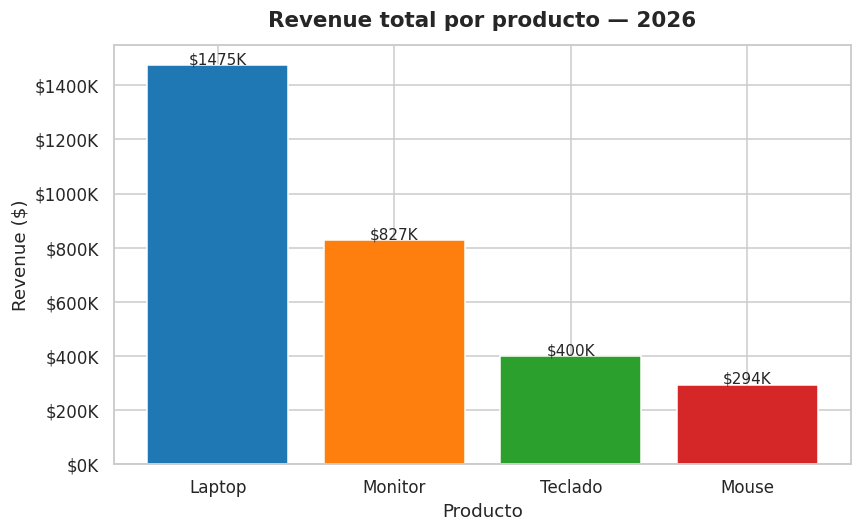

In [6]:
plt.figure(figsize=(8, 5))
bars = plt.bar(rev_prod['Producto'], rev_prod['Revenue'],
               color=sns.color_palette('tab10', len(rev_prod)),
               edgecolor='white')

for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 4000,
             f'${h/1000:.0f}K', ha='center', fontsize=10)

plt.title('Revenue total por producto — 2026', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

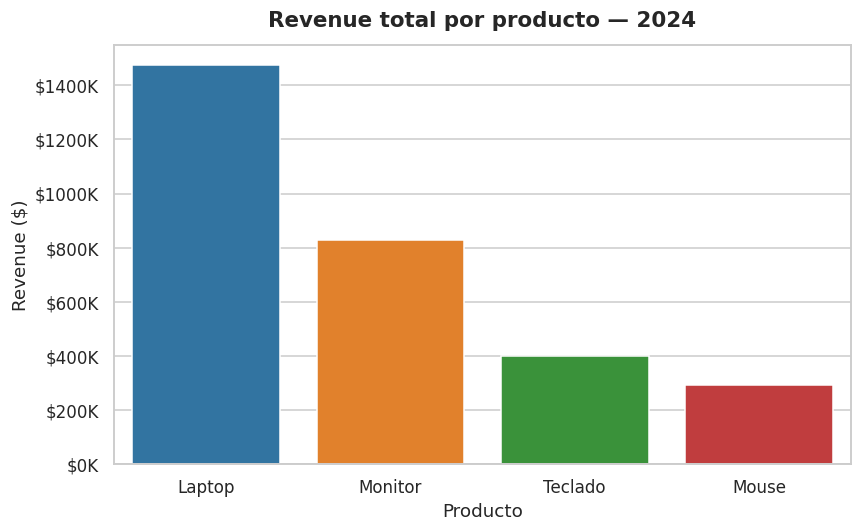

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(data=rev_prod, x='Producto', y='Revenue',
            hue='Producto', legend=False)

plt.title('Revenue total por producto — 2024', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()


> **Matplotlib vs Seaborn:** Matplotlib requiere iterar sobre las barras para agregar etiquetas de valor (`bar.get_height()`). Seaborn lo hace automáticamente si se agrega `ax.bar_label()`, o se usa el parámetro interno. La diferencia de código es significativa para personalizaciones como formateo de ejes.
>
> **Interpretación:** Compara **magnitudes absolutas** entre categorías. La altura de la barra es el único canal visual — lo que hace que las barras sean precisas pero también limitadas: solo muestran un valor por categoría.
> - El ordenamiento por valor (`sort_values`) facilita la lectura: la categoría mayor siempre está en el mismo extremo.
> - Evitar usar más de ~8-10 barras; con muchas categorías conviene agrupar o usar un gráfico de puntos (`dotplot`).
> - Si el eje no arranca en cero, la comparación visual queda distorsionada — siempre verificar el origen del eje Y.


---
## 3. Histogram — Distribución de una variable

**Dato:** distribución del revenue por transacción.

#### 🔵 Matplotlib

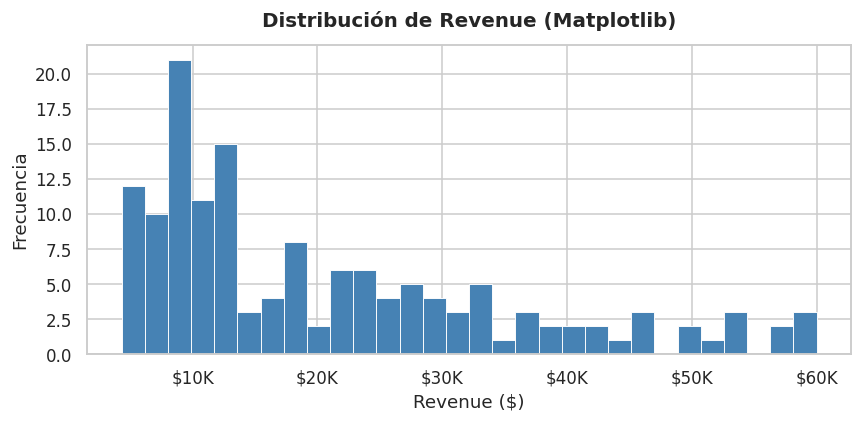

In [8]:
plt.figure(figsize=(8, 4))
plt.hist(df['Revenue'], bins=30, color='steelblue',
         edgecolor='white', linewidth=0.6)

plt.title('Distribución de Revenue (Matplotlib)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Revenue ($)')
plt.ylabel('Frecuencia')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

> `kde=True` agrega la curva de densidad (KDE) sin código extra.

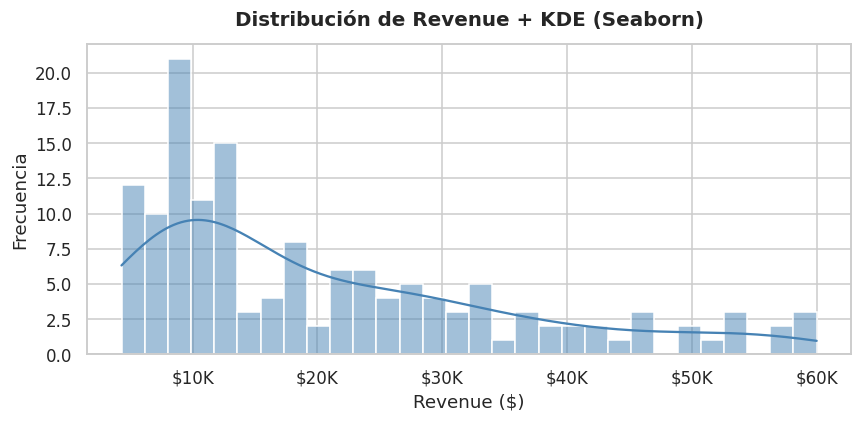

Media:        $20,809
Mediana:      $15,600
Asimetría G1: 1.0611


In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Revenue'], bins=30, kde=True, color='steelblue')

plt.title('Distribución de Revenue + KDE (Seaborn)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Revenue ($)')
plt.ylabel('Frecuencia')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

print(f"Media:        ${df['Revenue'].mean():,.0f}")
print(f"Mediana:      ${df['Revenue'].median():,.0f}")
print(f"Asimetría G1: {df['Revenue'].skew():.4f}")


> **Matplotlib vs Seaborn:** `plt.hist()` produce un histograma básico. `sns.histplot(..., kde=True)` agrega la curva de densidad (KDE) con un solo parámetro, sin necesidad de calcularla manualmente.
>
> **Interpretación:** Muestra la **distribución de frecuencias** de una variable continua. Claves para leer:
> - **Forma**: ¿campana simétrica (distribución normal), sesgada a la derecha (cola larga en valores altos, como ingresos o precios) o bimodal (dos picos, que suele indicar dos sub-poblaciones mezcladas)?
> - **Coeficiente de asimetría (skewness)**: valor ≈ 0 → simétrico; positivo → cola derecha (sesgo positivo); negativo → cola izquierda.
> - **Centro**: la moda es el bin más alto; la media y mediana se calculan por separado. Si media > mediana, hay sesgo positivo.
> - **Dispersión**: bins altos y concentrados = poca variabilidad; bins bajos y extendidos = mucha variabilidad.
> - **Ancho de bin** (`bins`): muy pocos bins suavizan demasiado y ocultan estructura; demasiados crean ruido — ajustar según el tamaño del dataset.


---
## 4. Box Plot — Distribución + outliers

**Dato:** distribución del revenue por región.

#### 🔵 Matplotlib

/tmp/ipykernel_38207/2858168402.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(datos_box, labels=REGIONES, patch_artist=True)


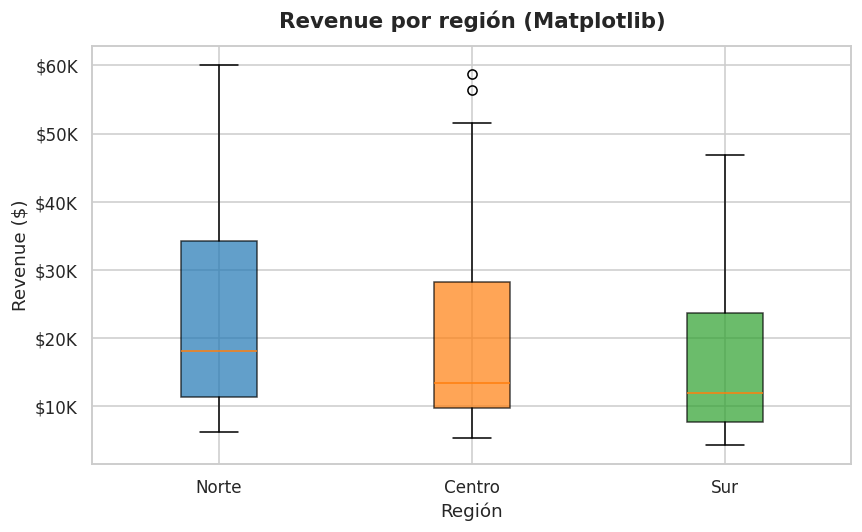

In [10]:
datos_box = [df[df['Region'] == r]['Revenue'].values for r in REGIONES]

plt.figure(figsize=(8, 5))
bp = plt.boxplot(datos_box, labels=REGIONES, patch_artist=True)

colores = sns.color_palette('tab10', len(REGIONES))
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.title('Revenue por región (Matplotlib)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Región')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

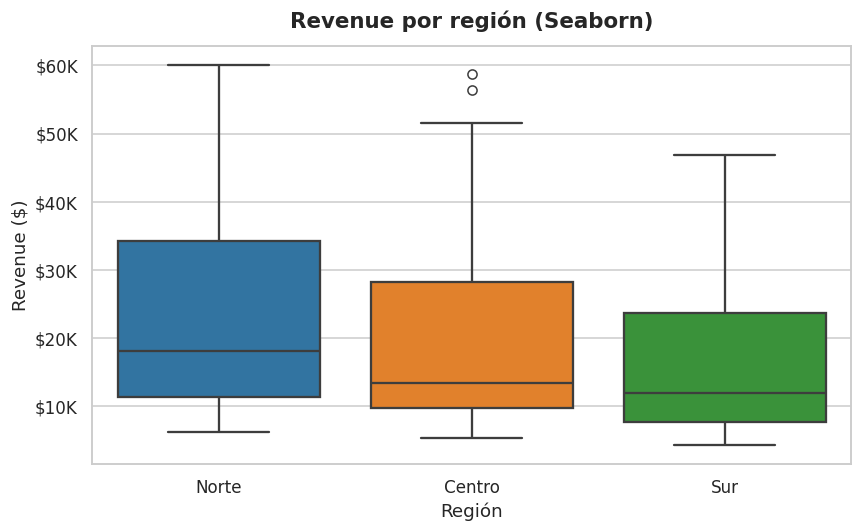

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Region', y='Revenue',
            hue='Region', legend=False, linewidth=1.5)

plt.title('Revenue por región (Seaborn)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Región')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()


> **Matplotlib vs Seaborn:** Matplotlib requiere preparar los datos como lista de arrays (`[df[df['Region'] == r]['Revenue'].values for r in REGIONES]`) y luego colorear manualmente cada caja. Seaborn acepta directamente el DataFrame y aplica `hue` para colorear.
>
> **Interpretación:** El box plot resume la distribución en 5 estadísticos:
> - **Caja (Q1–Q3)**: contiene el 50% central de los datos — el rango intercuartílico (IQR).
> - **Línea interior**: mediana (Q2) — el valor que divide el 50% superior del inferior.
> - **Bigotes**: se extienden hasta 1.5 × IQR desde los bordes de la caja.
> - **Puntos fuera de los bigotes**: outliers — valores inusualmente altos o bajos.
>
> Para comparar grupos: si las cajas no se superponen, los grupos difieren significativamente. Si las medianas están alineadas pero las cajas tienen distinto tamaño, la variabilidad es diferente aunque el centro sea similar.


---
## 5. Violin Plot — Distribución con forma

**Dato:** distribución del revenue por producto.

#### 🔵 Matplotlib

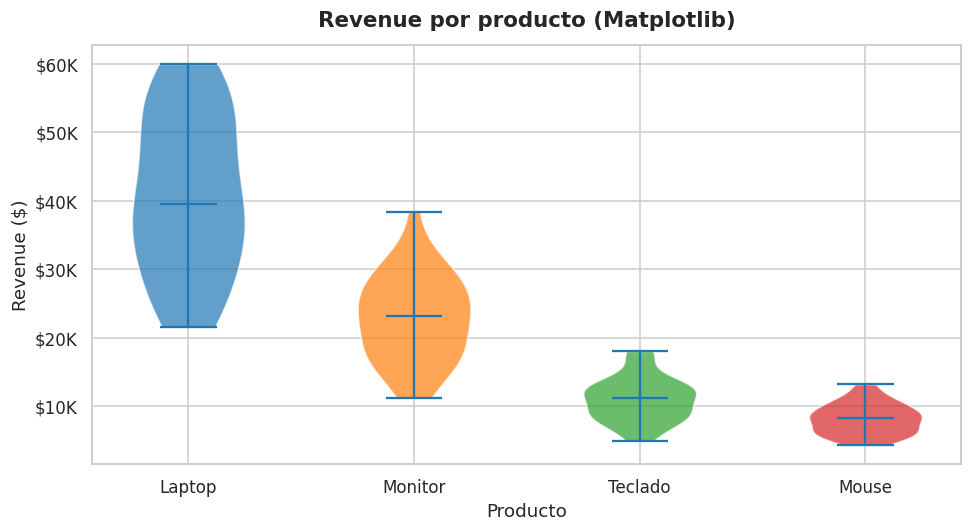

In [12]:
datos_violin = [df[df['Producto'] == p]['Revenue'].values for p in PRODUCTOS]

plt.figure(figsize=(9, 5))
parts = plt.violinplot(datos_violin, positions=range(1, len(PRODUCTOS) + 1),
                       showmedians=True)

colores = sns.color_palette('tab10', len(PRODUCTOS))
for pc, color in zip(parts['bodies'], colores):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

plt.xticks(range(1, len(PRODUCTOS) + 1), PRODUCTOS)
plt.title('Revenue por producto (Matplotlib)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

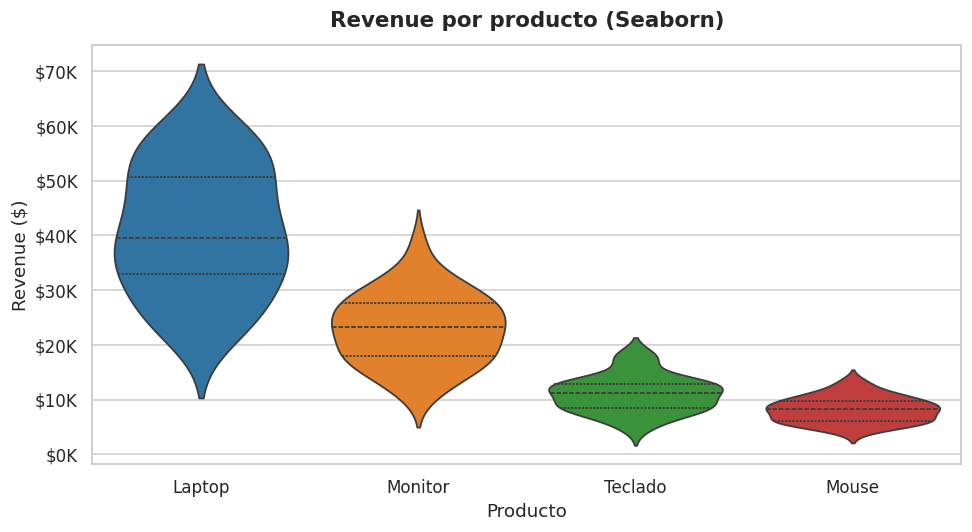

In [13]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='Producto', y='Revenue',
               hue='Producto', legend=False,
               inner='quartile', linewidth=1.2)

plt.title('Revenue por producto (Seaborn)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()


> **Matplotlib vs Seaborn:** `plt.violinplot()` requiere configurar manualmente los colores de cada "cuerpo" iterando sobre `parts['bodies']`. `sns.violinplot()` aplica `hue` directamente y el parámetro `inner='quartile'` agrega las líneas de los cuartiles dentro del violín.
>
> **Interpretación:** El violin plot extiende el box plot mostrando la **forma completa de la distribución** (estimada por KDE). La **anchura** del violín en cada altura indica cuántos datos hay en ese rango de valores.
> - Un violín **simétrico y con una sola barriga** → distribución aproximadamente normal.
> - Un violín **más ancho arriba** → la mayoría de los valores son altos (sesgo negativo).
> - Un violín con **dos barrigas** (bimodal) → hay dos sub-grupos mezclados con centros distintos.
> - Las líneas internas (`inner='quartile'`) muestran Q1, mediana y Q3, igual que en el box plot.
> - Ventaja sobre el box plot: **no oculta la forma**; útil cuando la distribución es irregular o bimodal.


---
## 6. Scatter Plot — Relación entre dos variables

**Dato:** cantidad vendida vs revenue, coloreado por región.

#### 🔵 Matplotlib

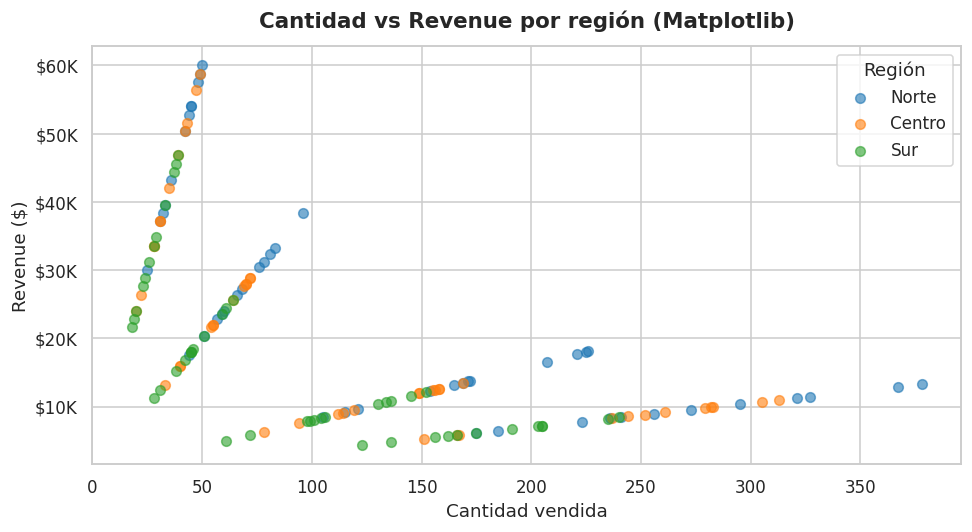

In [14]:
plt.figure(figsize=(9, 5))
for region in REGIONES:
    datos = df[df['Region'] == region]
    plt.scatter(datos['Cantidad'], datos['Revenue'],
                label=region, alpha=0.6, s=40)

plt.title('Cantidad vs Revenue por región (Matplotlib)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Cantidad vendida')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

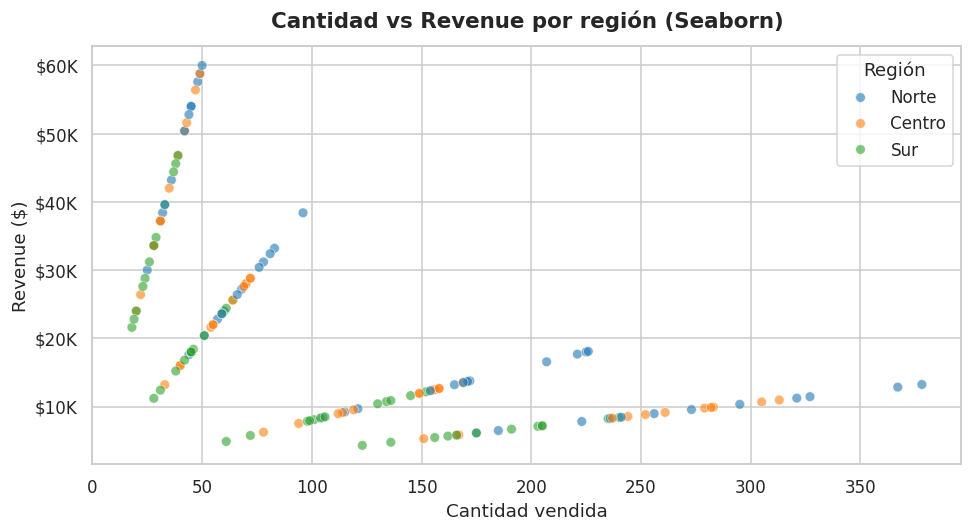

In [15]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Cantidad', y='Revenue',
                hue='Region', alpha=0.6, s=40)

plt.title('Cantidad vs Revenue por región (Seaborn)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Cantidad vendida')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Región')
plt.tight_layout()
plt.show()


> **Matplotlib vs Seaborn:** Misma estructura que el line plot — Matplotlib itera manualmente (`for region`), Seaborn usa `hue`. El parámetro `alpha` controla la transparencia de los puntos, útil cuando hay superposición (overplotting).
>
> **Interpretación:** Muestra la **relación entre dos variables continuas**. Cada punto es una observación.
> - **Dirección**: correlación positiva (ambas suben juntas), negativa (una baja cuando la otra sube) o ninguna (nube dispersa sin patrón).
> - **Fuerza**: puntos concentrados cerca de una línea diagonal → relación fuerte; puntos dispersos en nube → relación débil.
> - **Clusters por color** (`hue`): si los grupos forman nubes separadas, las variables tienen comportamiento distinto por grupo; si se mezclan, el grupo no influye en esa relación.
> - **Outliers**: puntos muy alejados del patrón merecen investigación — pueden ser errores de carga, transacciones excepcionales o casos de negocio relevantes.


---
## 7. Heatmap — Datos en grilla

**Dato:** revenue mensual por producto (pivot mes × producto).

In [16]:
pivot = (
    df.groupby(['Mes', 'Producto'])['Revenue']
    .sum().unstack().reindex(MESES)
)

#### 🔵 Matplotlib

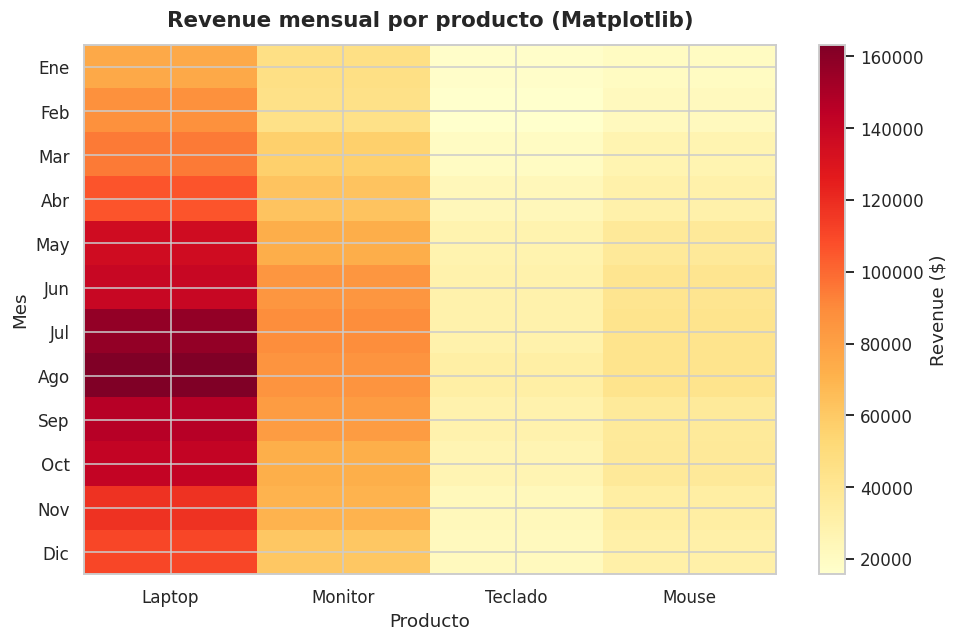

In [17]:
plt.figure(figsize=(9, 6))
img = plt.imshow(pivot.values, cmap='YlOrRd', aspect='auto')
plt.colorbar(img, label='Revenue ($)')

plt.xticks(range(len(PRODUCTOS)), PRODUCTOS)
plt.yticks(range(len(MESES)), MESES)
plt.title('Revenue mensual por producto (Matplotlib)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()

#### 🟠 Seaborn

> `annot=True` agrega el valor numérico en cada celda automáticamente.

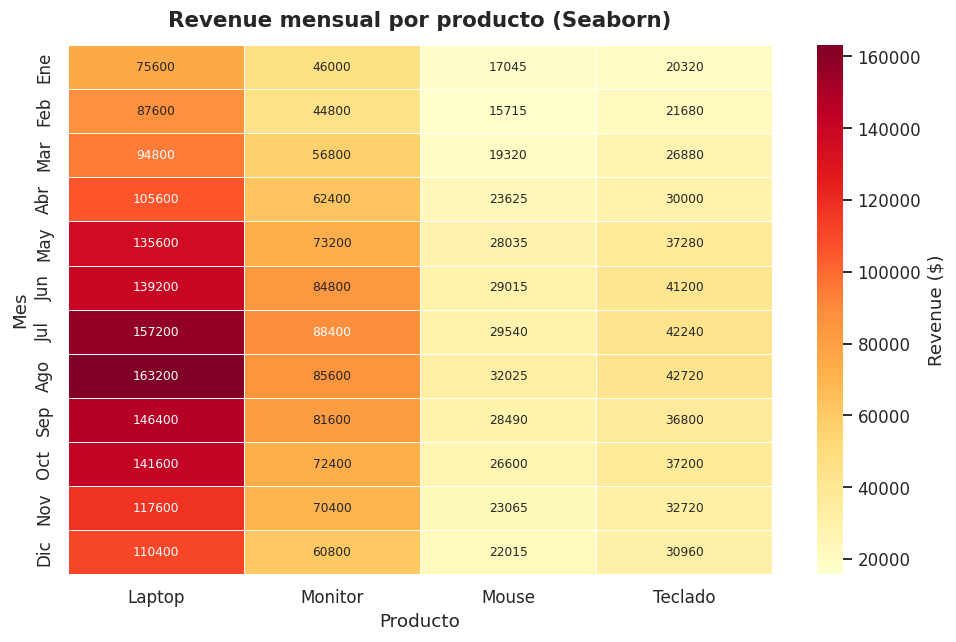

In [18]:
plt.figure(figsize=(9, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f',
            annot_kws={'size': 8}, linewidths=0.5,
            cbar_kws={'label': 'Revenue ($)'})

plt.title('Revenue mensual por producto (Seaborn)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Producto')
plt.ylabel('Mes')
plt.tight_layout()
plt.show()


> **Matplotlib vs Seaborn:** `plt.imshow()` requiere pasar `pivot.values` (array NumPy) y configurar manualmente los ejes con `plt.xticks`/`plt.yticks`. `sns.heatmap()` acepta directamente el DataFrame y usa los índices/columnas como etiquetas. `annot=True` agrega automáticamente el valor numérico en cada celda — en Matplotlib esto requiere un bucle doble.
>
> **Interpretación:** Codifica la **intersección de dos variables categóricas** como color. Permite detectar patrones de una ojeada:
> - **Celdas más oscuras/intensas** → valores más altos en esa combinación de fila y columna.
> - **Lectura por fila**: en cada período/categoría, ¿qué columna es más alta? (ej: ¿qué producto vendió más en junio?)
> - **Lectura por columna**: en cada producto/categoría, ¿en qué período rinde mejor?
> - **Bloques**: un cluster de celdas oscuras indica una combinación que sistemáticamente supera al resto.
> - **Truco crítico**: `unstack()[MESES]` reordena las columnas cronológicamente. Sin esto, `unstack()` ordena alfabéticamente (Abr, Ago, Dic...) y el heatmap pierde sentido temporal.


---
## 8. Pair Plot — Solo Seaborn

Genera scatter plots entre todos los pares de variables numéricas. No tiene equivalente directo en Matplotlib puro.

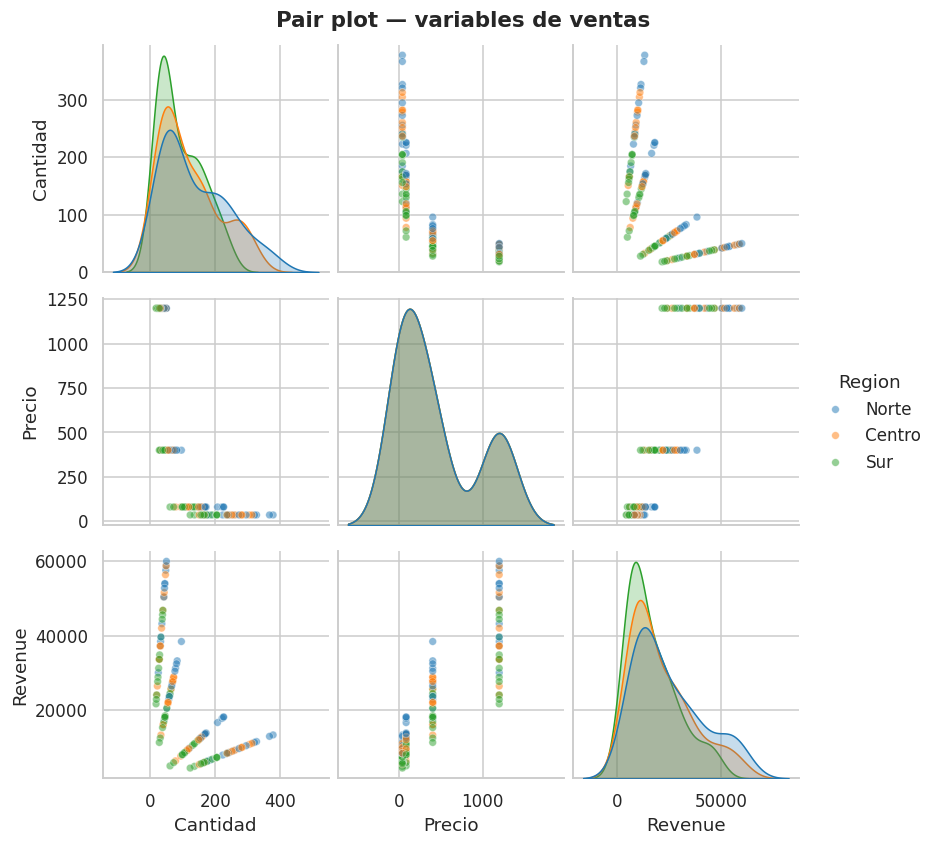

In [19]:
g = sns.pairplot(
    df[['Cantidad', 'Precio', 'Revenue', 'Region']],
    hue='Region',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 25},
    height=2.5
)
g.figure.suptitle('Pair plot — variables de ventas', y=1.02,
                  fontsize=14, fontweight='bold')
plt.show()


> **Solo Seaborn:** No existe equivalente directo en Matplotlib puro — requeriría construir la grilla manualmente con `plt.subplots()` y llamar a `plt.scatter()` en cada celda. `sns.pairplot()` genera automáticamente todos los cruces posibles entre las variables numéricas seleccionadas.
>
> **Interpretación:** Genera una **matriz de scatter plots** para explorar todas las relaciones bivariadas de un dataset en un solo gráfico.
> - **Diagonal**: distribución de cada variable por separado (`diag_kind='kde'` muestra la curva de densidad).
> - **Celdas fuera de la diagonal**: scatter plot entre el par de variables de esa fila y columna.
> - **Color** (`hue`): permite ver si los grupos forman clusters distintos en cada combinación.
> - Útil para **análisis exploratorio inicial**: detectar correlaciones fuertes, variables con distribuciones sesgadas, y pares que merecen un análisis más profundo.
> - En datasets con muchas columnas, seleccionar solo las variables relevantes — con 10+ columnas la grilla se vuelve ilegible.


---
## 9. Dashboards — Solo Seaborn

Múltiples gráficos en una figura con `plt.subplots()`. Acá sí necesitamos el eje explícito (`ax`) para indicarle a seaborn dónde dibujar cada gráfico.

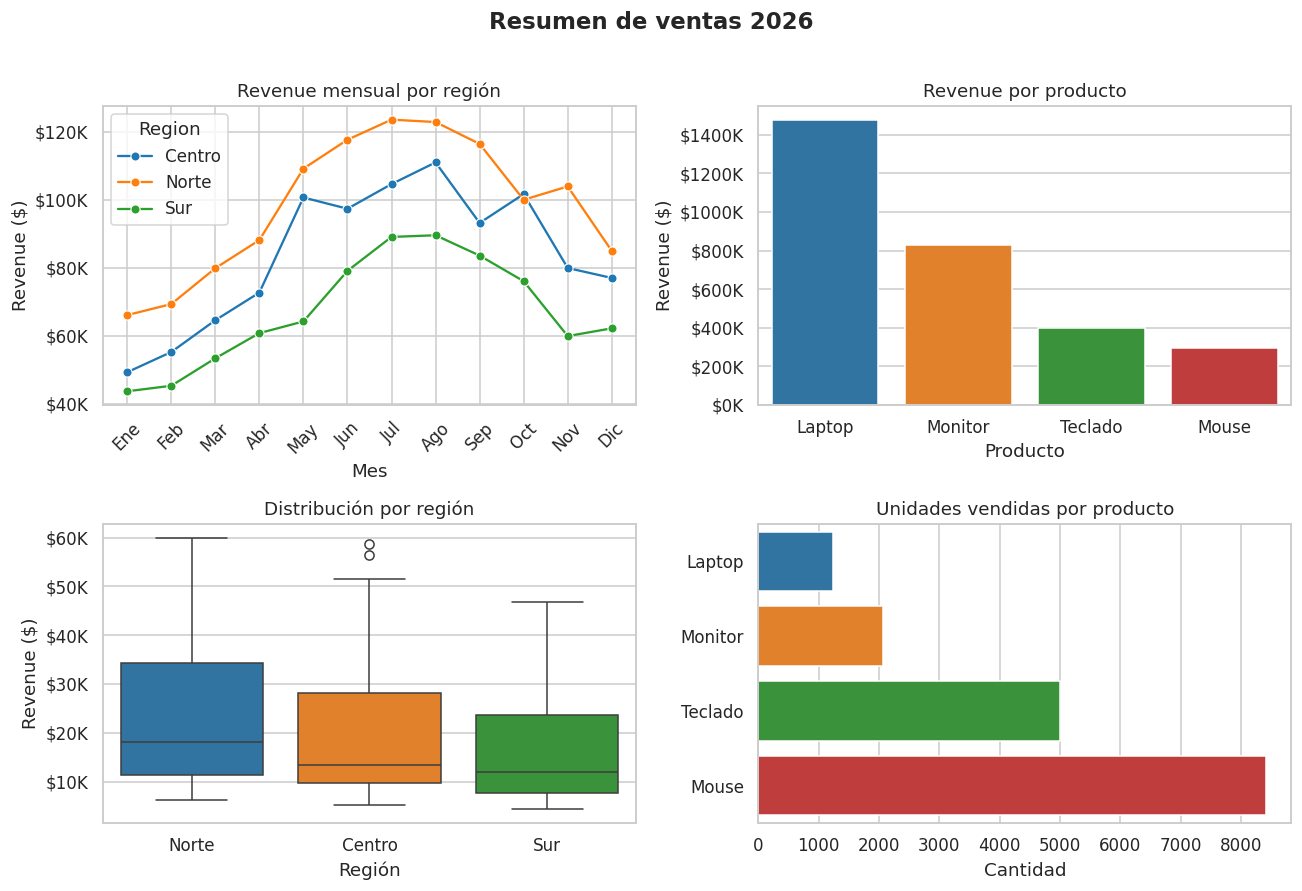

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Resumen de ventas 2026', fontsize=15, fontweight='bold', y=1.01)

# ── Panel 1: Revenue mensual ──────────────────────────────────────
rev_mes_region = (
    df.groupby(['MesNum', 'Region'])['Revenue'].sum().reset_index()
)
sns.lineplot(data=rev_mes_region, x='MesNum', y='Revenue',
             hue='Region', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Revenue mensual por región')
axes[0, 0].set_xlabel('Mes')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(MESES, rotation=45)
axes[0, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 2: Revenue por producto ────────────────────────────────
rev_prod = df.groupby('Producto')['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False)
sns.barplot(data=rev_prod, x='Producto', y='Revenue',
            hue='Producto', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Revenue por producto')
axes[0, 1].set_xlabel('Producto')
axes[0, 1].set_ylabel('Revenue ($)')
axes[0, 1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 3: Box plot por región ──────────────────────────────────
sns.boxplot(data=df, x='Region', y='Revenue',
            hue='Region', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Distribución por región')
axes[1, 0].set_xlabel('Región')
axes[1, 0].set_ylabel('Revenue ($)')
axes[1, 0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 4: Cantidad por producto ───────────────────────────────
cant_prod = df.groupby('Producto')['Cantidad'].sum().reset_index().sort_values('Cantidad')
sns.barplot(data=cant_prod, x='Cantidad', y='Producto',
            hue='Producto', legend=False,
            orient='h', ax=axes[1, 1])
axes[1, 1].set_title('Unidades vendidas por producto')
axes[1, 1].set_xlabel('Cantidad')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()


> **Construcción:** `fig, axes = plt.subplots(rows, cols)` crea la grilla de ejes. Cada función de Seaborn recibe `ax=axes[i, j]` para indicarle en qué panel dibujar. Sin el parámetro `ax`, Seaborn crea una figura nueva en lugar de dibujar en el panel indicado.
>
> **Interpretación:** Un dashboard yuxtapone múltiples perspectivas para **lectura cruzada** sin cambiar de gráfico.
> - ¿La región con mayor revenue mensual (panel superior izquierdo) tiene también mayor dispersión (panel inferior izquierdo)?
> - ¿El producto líder en revenue (panel superior derecho) también lidera en unidades vendidas (panel inferior derecho)?
> - Este formato es el estándar en reportes ejecutivos: permite identificar contradicciones o coherencias entre métricas en un solo vistazo.
> - Para 5+ paneles, usar `GridSpec` (ver Ejercicio 5) que permite controlar el tamaño relativo de cada panel y combinar celdas para gráficos más anchos.


---
## 10. Widgets interactivos — `ipywidgets`

`ipywidgets` permite agregar controles interactivos (sliders, dropdowns, botones) directamente en la notebook.

```bash
pip install ipywidgets
```

El decorador `@interact` conecta automáticamente el widget con la función: cada vez que el usuario mueve el control, la función se vuelve a ejecutar y el gráfico se actualiza.

In [21]:
import ipywidgets as widgets
from ipywidgets import interact
print('ipywidgets listo')

ipywidgets listo


### 🎚️ Slider — Filtrar rango de meses

Un `IntRangeSlider` permite seleccionar un rango numérico con dos manijas.
El gráfico muestra el revenue mensual solo para el rango elegido.

In [22]:
def grafico_slider(rango_meses):
    mes_ini, mes_fin = rango_meses

    datos = (
        df[(df['MesNum'] >= mes_ini) & (df['MesNum'] <= mes_fin)]
        .groupby(['MesNum', 'Region'])['Revenue']
        .sum().reset_index()
    )

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=datos, x='MesNum', y='Revenue',
                 hue='Region', marker='o')

    plt.title(f'Revenue mensual — meses {MESES[mes_ini-1]} a {MESES[mes_fin-1]}',
              fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Mes')
    plt.ylabel('Revenue ($)')
    plt.xticks(
        ticks=range(mes_ini, mes_fin + 1),
        labels=MESES[mes_ini - 1: mes_fin]
    )
    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
    )
    plt.legend(title='Región')
    plt.tight_layout()
    plt.show()


slider_meses = widgets.IntRangeSlider(
    value=[1, 12],
    min=1, max=12, step=1,
    description='Meses:',
    continuous_update=False,
    layout=widgets.Layout(width='500px'),
)

interact(grafico_slider, rango_meses=slider_meses)


interactive(children=(IntRangeSlider(value=(1, 12), continuous_update=False, description='Meses:', layout=Layo…

<function __main__.grafico_slider(rango_meses)>

### 📋 Dropdown — Seleccionar región

Un `Dropdown` permite elegir un valor de una lista.
El gráfico muestra el revenue por producto para la región seleccionada.

In [23]:
def grafico_dropdown(region):
    datos = (
        df[df['Region'] == region]
        .groupby(['MesNum', 'Producto'])['Revenue']
        .sum().reset_index()
    )

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=datos, x='MesNum', y='Revenue',
                 hue='Producto', marker='o')

    plt.title(f'Revenue mensual por producto — Región {region}',
              fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Mes')
    plt.ylabel('Revenue ($)')
    plt.xticks(ticks=range(1, 13), labels=MESES)
    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
    )
    plt.legend(title='Producto')
    plt.tight_layout()
    plt.show()


dropdown_region = widgets.Dropdown(
    options=REGIONES,
    value='Norte',
    description='Región:',
)

interact(grafico_dropdown, region=dropdown_region)


interactive(children=(Dropdown(description='Región:', options=('Norte', 'Centro', 'Sur'), value='Norte'), Outp…

<function __main__.grafico_dropdown(region)>

### 🎚️ + 📋 Combinado — Slider y Dropdown juntos

Se pueden combinar múltiples widgets en una misma función.
Acá filtramos por región (dropdown) y tipo de gráfico (dropdown) simultáneamente.

In [24]:
def grafico_combinado(region, top_n):
    top_productos = (
        df[df['Region'] == region]
        .groupby('Producto')['Revenue']
        .sum()
        .nlargest(top_n)
        .index.tolist()
    )

    datos = (
        df[(df['Region'] == region) & (df['Producto'].isin(top_productos))]
        .groupby(['MesNum', 'Producto'])['Revenue']
        .sum().reset_index()
    )

    plt.figure(figsize=(9, 4))
    sns.lineplot(data=datos, x='MesNum', y='Revenue',
                 hue='Producto', marker='o')

    plt.title(f'Top {top_n} productos — Región {region}',
              fontsize=13, fontweight='bold', pad=10)
    plt.xlabel('Mes')
    plt.ylabel('Revenue ($)')
    plt.xticks(ticks=range(1, 13), labels=MESES)
    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
    )
    plt.legend(title='Producto')
    plt.tight_layout()
    plt.show()


dropdown_region2 = widgets.Dropdown(
    options=REGIONES,
    value='Norte',
    description='Región:',
)

slider_top_n = widgets.IntSlider(
    value=4,
    min=1, max=4, step=1,
    description='Top N productos:',
    continuous_update=False,
    layout=widgets.Layout(width='400px'),
)

interact(grafico_combinado, region=dropdown_region2, top_n=slider_top_n)


interactive(children=(Dropdown(description='Región:', options=('Norte', 'Centro', 'Sur'), value='Norte'), IntS…

<function __main__.grafico_combinado(region, top_n)>


> **Construcción:** `@interact` / `interact(funcion, widget=...)` conecta un control interactivo con una función Python. Cada vez que el usuario mueve el control, la función se re-ejecuta automáticamente con el nuevo valor. Los widgets disponibles incluyen `IntSlider`, `IntRangeSlider`, `Dropdown`, `Checkbox`, `Text`, entre otros.
>
> **Cuándo usar widgets:**
> - **Exploración interactiva**: permiten filtrar, segmentar o cambiar parámetros sin re-ejecutar celdas manualmente — muy útil para análisis exploratorio o presentaciones.
> - **Dashboards en notebook**: alternativa ligera a Dash o Streamlit para exploración interna, sin necesidad de un servidor web.
> - **Limitación**: los widgets solo funcionan con el kernel activo — no se preservan en exportaciones HTML estáticas ni en GitHub. Para dashboards compartibles, Plotly + HTML o Streamlit son mejores opciones.
> - `continuous_update=False` evita que el gráfico se recalcule en cada pixel de movimiento del slider — recomendable cuando el recálculo es costoso.


---
## ✏️ Ejercicios

**Ejercicio 1.** Repetí el line plot de la sección 1 pero mostrando **cantidad vendida** en lugar de revenue. Hacelo en ambas librerías.

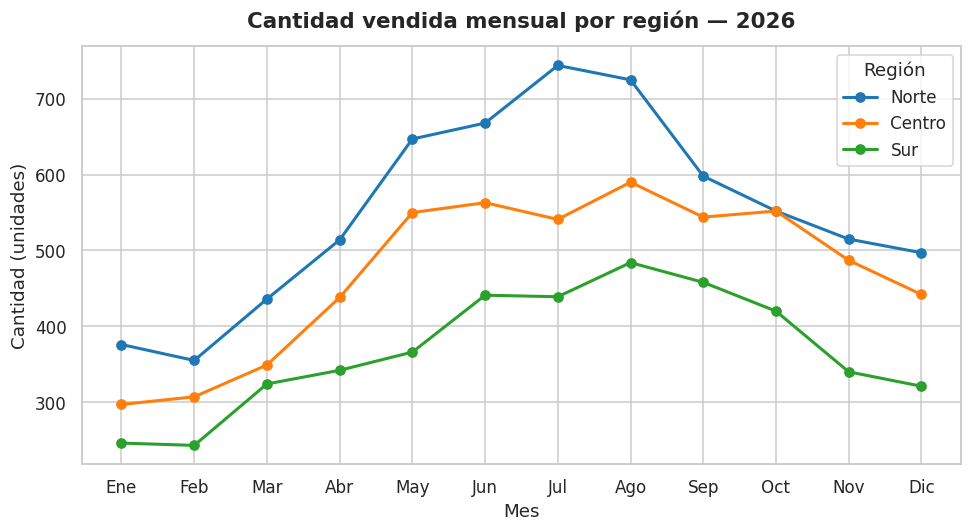

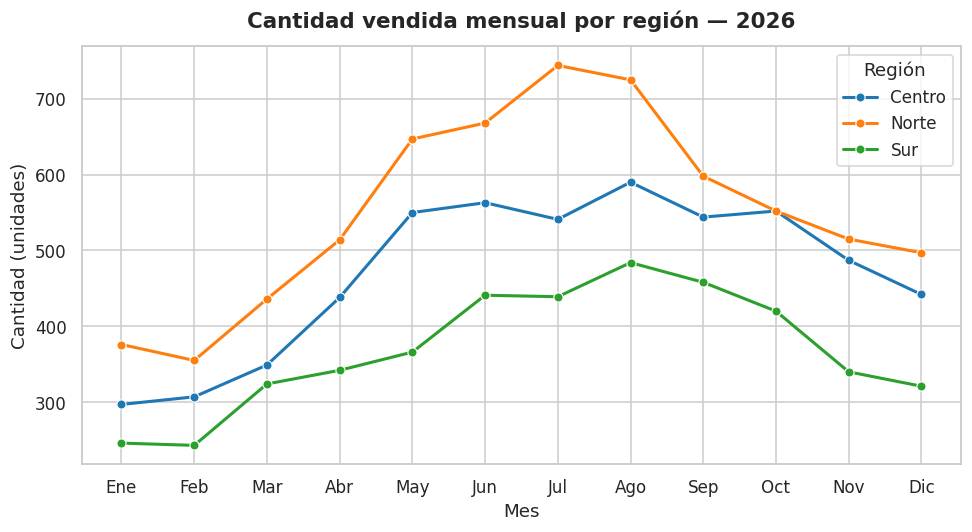

In [25]:
# Ejercicio 1 — Line plot de cantidad vendida por región

# Preparación del dato: cantidad mensual por región
cant_mes_region = (
    df.groupby(['MesNum', 'Region'])['Cantidad']
    .sum().reset_index()
)

# ── 🔵 Matplotlib ──────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
for region in REGIONES:
    datos = cant_mes_region[cant_mes_region['Region'] == region]
    plt.plot(MESES, datos['Cantidad'], marker='o', linewidth=2, label=region)

plt.title('Cantidad vendida mensual por región — 2026', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Cantidad (unidades)')
plt.legend(title='Región')
plt.tight_layout()
plt.show()

# ── 🟠 Seaborn ─────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
sns.lineplot(data=cant_mes_region, x='MesNum', y='Cantidad',
             hue='Region', marker='o', linewidth=2)

plt.title('Cantidad vendida mensual por región — 2026', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Cantidad (unidades)')
plt.xticks(ticks=range(1, 13), labels=MESES)
plt.legend(title='Región')
plt.tight_layout()
plt.show()


**Ejercicio 2.** Hacé un bar plot horizontal con el revenue por región. Hacelo en ambas librerías.

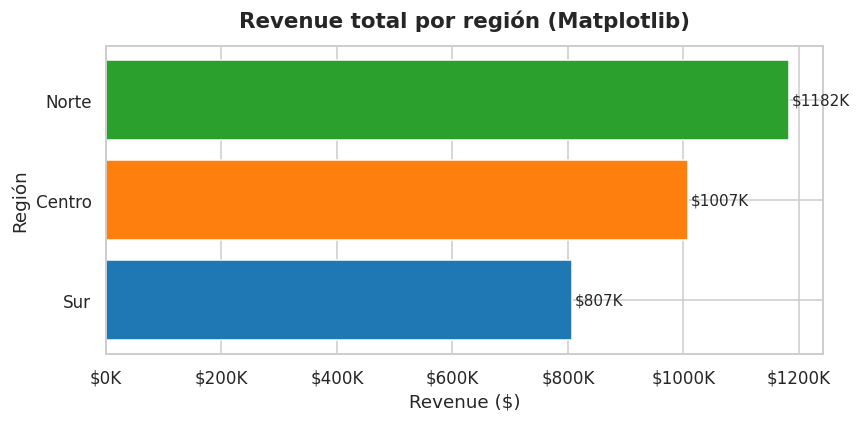

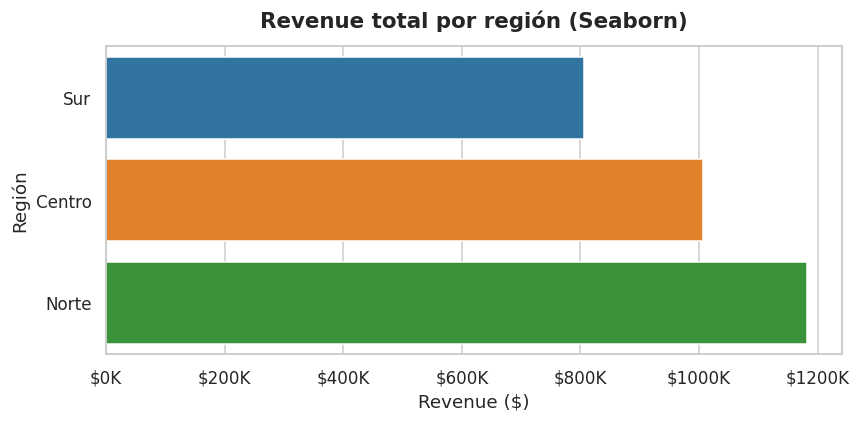

In [26]:
# Ejercicio 2 — Bar plot horizontal de revenue por región

# Preparación del dato: revenue total por región
rev_region = (
    df.groupby('Region')['Revenue']
    .sum().reset_index()
    .sort_values('Revenue', ascending=True)   # ascending=True para que el mayor quede arriba
)

# ── 🔵 Matplotlib ──────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
bars = plt.barh(rev_region['Region'], rev_region['Revenue'],
                color=sns.color_palette('tab10', len(rev_region)),
                edgecolor='white')

for bar in bars:
    w = bar.get_width()
    plt.text(w + 5000, bar.get_y() + bar.get_height() / 2,
             f'${w/1000:.0f}K', va='center', fontsize=10)

plt.title('Revenue total por región (Matplotlib)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Revenue ($)')
plt.ylabel('Región')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()

# ── 🟠 Seaborn ─────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
sns.barplot(data=rev_region, x='Revenue', y='Region',
            hue='Region', legend=False, orient='h')

plt.title('Revenue total por región (Seaborn)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Revenue ($)')
plt.ylabel('Región')
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.tight_layout()
plt.show()


**Ejercicio 3.** En el scatter plot (sección 6), reemplazá el color por producto en lugar de región. ¿Qué patrón aparece?

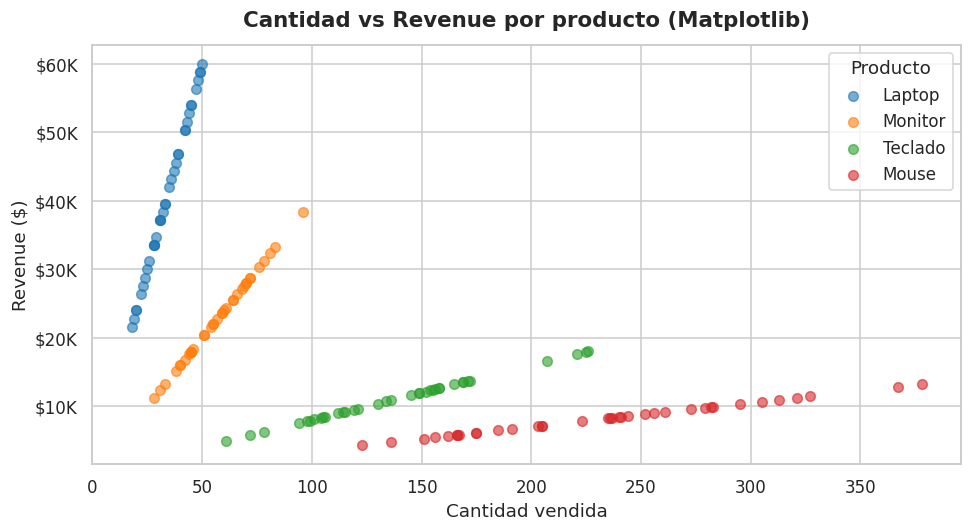

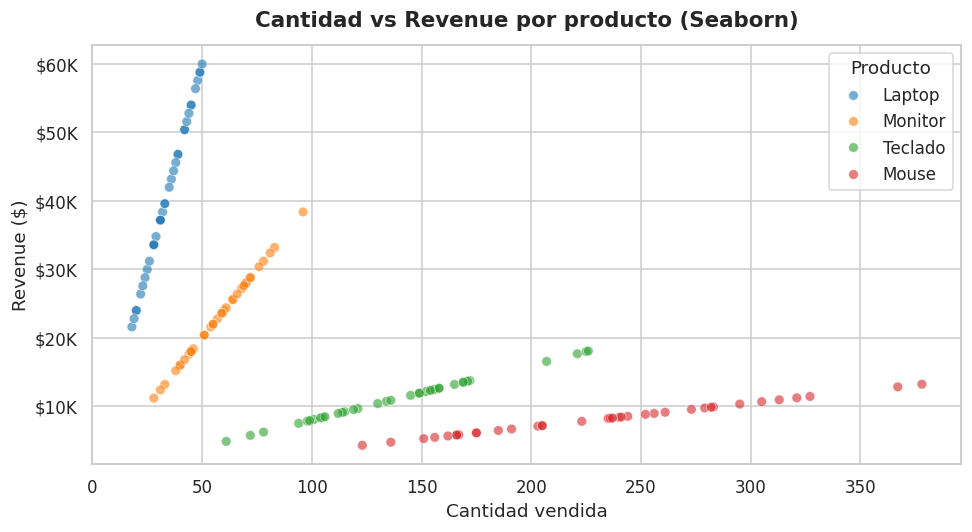

In [27]:
# Ejercicio 3 — Scatter plot coloreado por producto en lugar de región

# ── 🔵 Matplotlib ──────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
for producto in PRODUCTOS:
    datos = df[df['Producto'] == producto]
    plt.scatter(datos['Cantidad'], datos['Revenue'],
                label=producto, alpha=0.6, s=40)

plt.title('Cantidad vs Revenue por producto (Matplotlib)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Cantidad vendida')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Producto')
plt.tight_layout()
plt.show()

# ── 🟠 Seaborn ─────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Cantidad', y='Revenue',
                hue='Producto', alpha=0.6, s=40)

plt.title('Cantidad vs Revenue por producto (Seaborn)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Cantidad vendida')
plt.ylabel('Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
plt.legend(title='Producto')
plt.tight_layout()
plt.show()

# ── Patrón observado ───────────────────────────────────────────────
# Cada producto forma una banda diagonal bien separada de las demás.
# Esto se debe a que el precio es fijo por producto: Revenue = Cantidad × Precio.
# La relación es perfectamente lineal dentro de cada producto, con pendiente = precio.
# Laptop (precio $1200) forma la banda más alta; Mouse ($35) la más baja y horizontal.


**Ejercicio 4.** Creá un heatmap con el pivot de **cantidad** por región y mes (filas=Región, columnas=Mes).

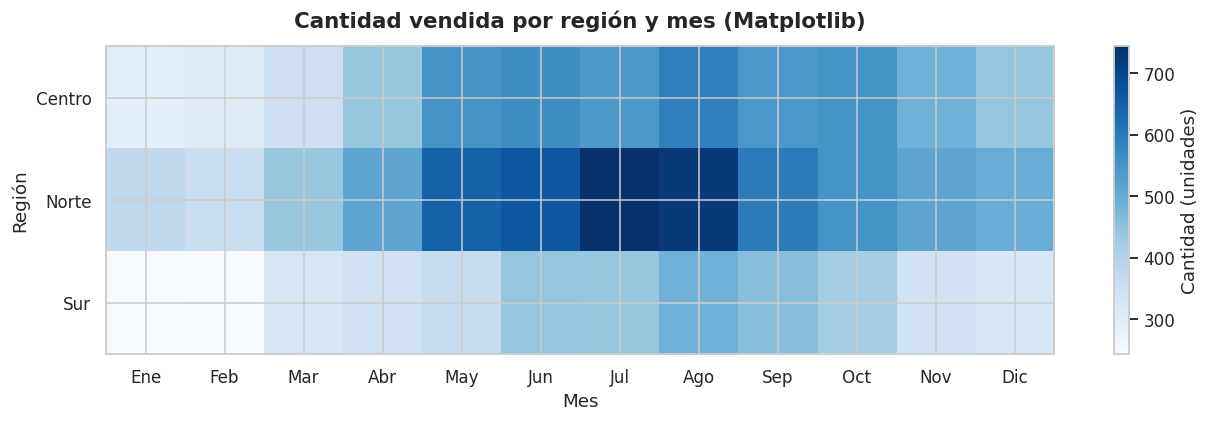

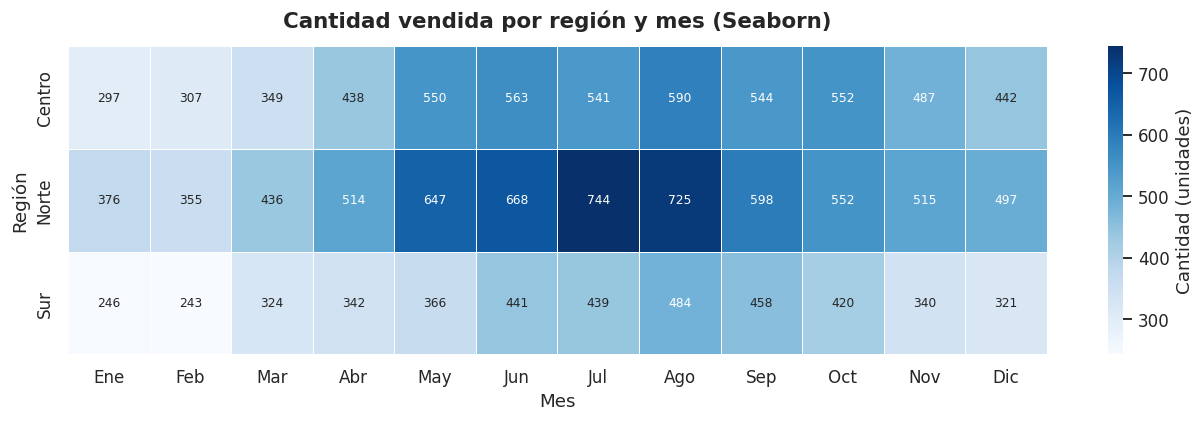

In [28]:
# Ejercicio 4 — Heatmap de cantidad por región y mes (filas=Región, columnas=Mes)

# Preparación del pivot: filas=Región, columnas=Mes (en orden cronológico)
pivot_cant = (
    df.groupby(['Region', 'Mes'])['Cantidad']
    .sum().unstack()[MESES]   # reordena columnas al orden cronológico
)

# ── 🔵 Matplotlib ──────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
img = plt.imshow(pivot_cant.values, cmap='Blues', aspect='auto')
plt.colorbar(img, label='Cantidad (unidades)')

plt.xticks(range(len(MESES)), MESES)
plt.yticks(range(len(REGIONES)), pivot_cant.index)
plt.title('Cantidad vendida por región y mes (Matplotlib)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Región')
plt.tight_layout()
plt.show()

# ── 🟠 Seaborn ─────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
sns.heatmap(pivot_cant, cmap='Blues', annot=True, fmt='.0f',
            annot_kws={'size': 8}, linewidths=0.5,
            cbar_kws={'label': 'Cantidad (unidades)'})

plt.title('Cantidad vendida por región y mes (Seaborn)',
          fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Mes')
plt.ylabel('Región')
plt.tight_layout()
plt.show()


**Ejercicio 5.** Extendé el dashboard de la sección 9 agregando un quinto panel: violin plot de revenue por producto.

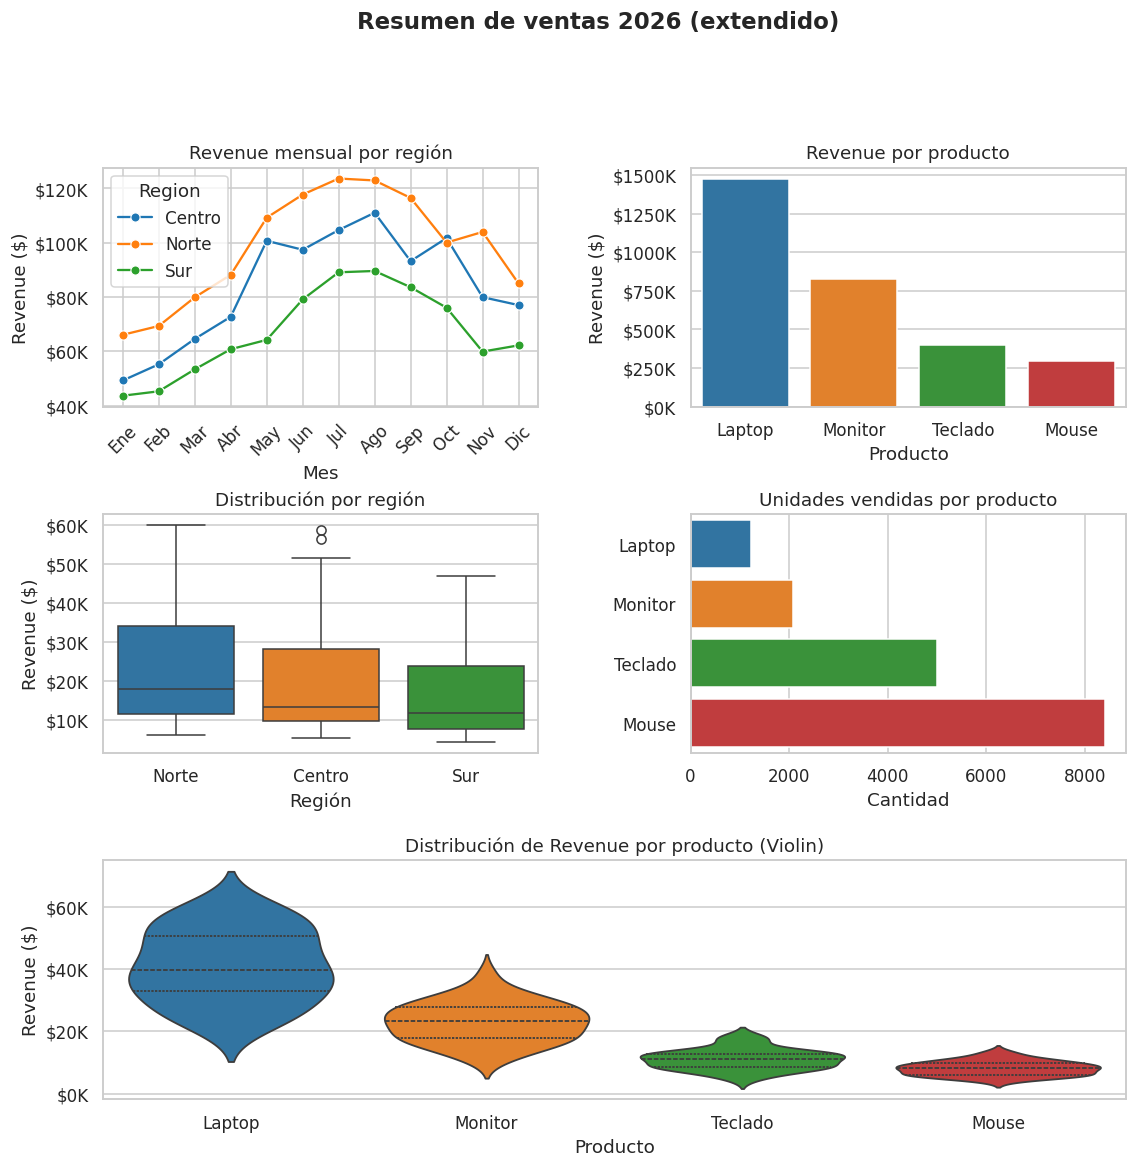

In [29]:
# Ejercicio 5 — Dashboard extendido con quinto panel: violin plot de revenue por producto
# Se usa GridSpec para que el panel 5 ocupe toda la fila inferior.

from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 11))
fig.suptitle('Resumen de ventas 2026 (extendido)', fontsize=15, fontweight='bold', y=1.01)

gs = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])
ax5 = fig.add_subplot(gs[2, :])   # ocupa toda la fila inferior

# ── Panel 1: Revenue mensual ──────────────────────────────────────
rev_mes_region = df.groupby(['MesNum', 'Region'])['Revenue'].sum().reset_index()
sns.lineplot(data=rev_mes_region, x='MesNum', y='Revenue',
             hue='Region', marker='o', ax=ax1)
ax1.set_title('Revenue mensual por región')
ax1.set_xlabel('Mes')
ax1.set_ylabel('Revenue ($)')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(MESES, rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 2: Revenue por producto ────────────────────────────────
rev_prod = df.groupby('Producto')['Revenue'].sum().reset_index().sort_values('Revenue', ascending=False)
sns.barplot(data=rev_prod, x='Producto', y='Revenue',
            hue='Producto', legend=False, ax=ax2)
ax2.set_title('Revenue por producto')
ax2.set_xlabel('Producto')
ax2.set_ylabel('Revenue ($)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 3: Box plot por región ──────────────────────────────────
sns.boxplot(data=df, x='Region', y='Revenue',
            hue='Region', legend=False, ax=ax3)
ax3.set_title('Distribución por región')
ax3.set_xlabel('Región')
ax3.set_ylabel('Revenue ($)')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# ── Panel 4: Cantidad por producto ───────────────────────────────
cant_prod = df.groupby('Producto')['Cantidad'].sum().reset_index().sort_values('Cantidad')
sns.barplot(data=cant_prod, x='Cantidad', y='Producto',
            hue='Producto', legend=False, orient='h', ax=ax4)
ax4.set_title('Unidades vendidas por producto')
ax4.set_xlabel('Cantidad')
ax4.set_ylabel('')

# ── Panel 5 (nuevo): Violin plot de revenue por producto ─────────
sns.violinplot(data=df, x='Producto', y='Revenue',
               hue='Producto', legend=False,
               inner='quartile', linewidth=1.2, ax=ax5)
ax5.set_title('Distribución de Revenue por producto (Violin)')
ax5.set_xlabel('Producto')
ax5.set_ylabel('Revenue ($)')
ax5.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.show()
